In [147]:
import pandas as pd 

In [148]:
dataFrame = pd.read_excel('bisiklet_verisi.xlsx')

In [149]:
dataFrame.head() #ilk 5 satırı gösterir.

,Fiyat,BisikletOzellik1,BisikletOzellik2
0,947.623770,1748.423445,1752.568469
1,1124.612636,1749.405172,1748.254459
2,518.774016,1751.744017,1748.352791
3,1066.607818,1753.144693,1748.877484
4,1170.385745,1746.838683,1753.383681


In [150]:
import seaborn as sbs
import matplotlib.pyplot as plt

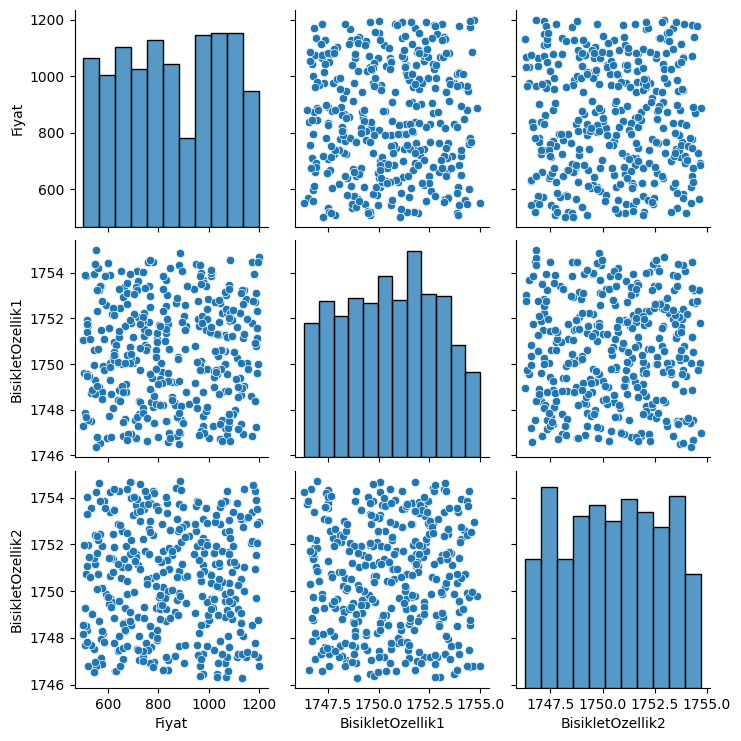

In [151]:
sbs.pairplot(dataFrame)

veriyi test/train olarak ikiye ayırmak

In [152]:
from sklearn.model_selection import train_test_split

In [153]:
#train_test_split()


In [154]:
#y = wx + b
y = dataFrame['Fiyat'].values

#x ->features (özellikler)
x = dataFrame[["BisikletOzellik1", "BisikletOzellik2"]].values

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=15)

In [155]:
x_train.shape

(670, 2)

In [156]:
x_test.shape

(330, 2)

In [157]:
y_train.shape

(670,)

In [158]:
y_test.shape

(330,)

In [159]:
from sklearn.preprocessing import MinMaxScaler

In [160]:
sclaler = MinMaxScaler()

In [161]:
sclaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [162]:
x_train = sclaler.transform(x_train)
x_test = sclaler.transform(x_test)

In [163]:
import tensorflow as tf
from tensorflow import keras

In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [216]:
model = Sequential()

model.add(Dense(4, activation = "relu"))
model.add(Dense(3, activation = "relu"))
model.add(Dense(4, activation = "relu"))

model.add(Dense(1))

model.compile(optimizer = "rmsprop", loss = "mse")

In [217]:
model.fit(x_train, y_train, epochs = 250)

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 785221.0000   
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 785087.7500 
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 784909.6250 
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 784741.9375 
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 784560.1875 
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 784358.3750 
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 784132.4375 
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 783873.4375 
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 783579.0625 
Epoch 10/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 783248.7500 
Epoch 11/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 782878.7500 
Epoch 12/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 782469.0000 
Epoch 13/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 782014.4375 
Epoch 14/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [218]:
loss = model.history.history['loss']

<Axes: >

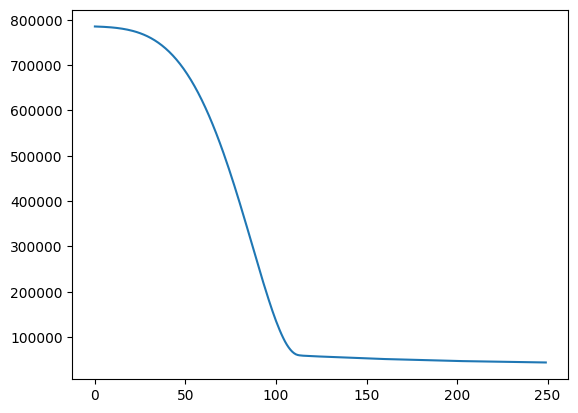

In [219]:
sbs.lineplot(x = range(len(loss)), y = loss)

In [220]:
trainLoss = model.evaluate(x_train, y_train, verbose=0)
testLoss = model.evaluate(x_test, y_test, verbose=0)

In [221]:
trainLoss

43750.30078125

In [222]:
testLoss

44633.0078125

In [223]:
testTahmin = model.predict(x_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [224]:
testTahmin.shape

(330, 1)

In [226]:
tahminDf = pd.DataFrame(y_test, columns = ["Tahmin"])

In [227]:
tahminDf

,Tahmin
0,1128.789327
1,766.651257
2,645.662559
3,578.118905
4,551.238466
...,...
325,609.117218
326,674.773611
327,903.604813
328,656.520189


In [228]:
testTahmin = pd.Series(testTahmin.reshape(330,))

In [229]:
testTahmin

0      814.375977
1      759.560059
2      824.920532
3      805.815430
4      891.718872
          ...    
325    982.329102
326    904.250610
327    830.238159
328    882.292358
329    945.531738
Length: 330, dtype: float32

In [230]:
tahminDf = pd.concat([tahminDf, testTahmin], axis = 1)

In [231]:
tahminDf

,Tahmin,0
0,1128.789327,814.375977
1,766.651257,759.560059
2,645.662559,824.920532
3,578.118905,805.815430
4,551.238466,891.718872
...,...,...
325,609.117218,982.329102
326,674.773611,904.250610
327,903.604813,830.238159
328,656.520189,882.292358


In [233]:
tahminDf.columns = ["Gerçek Değer", "Tahmin "]

In [234]:
tahminDf

,Gerçek Değer,Tahmin
0,1128.789327,814.375977
1,766.651257,759.560059
2,645.662559,824.920532
3,578.118905,805.815430
4,551.238466,891.718872
...,...,...
325,609.117218,982.329102
326,674.773611,904.250610
327,903.604813,830.238159
328,656.520189,882.292358


<Axes: xlabel='Gerçek Değer', ylabel='Tahmin '>

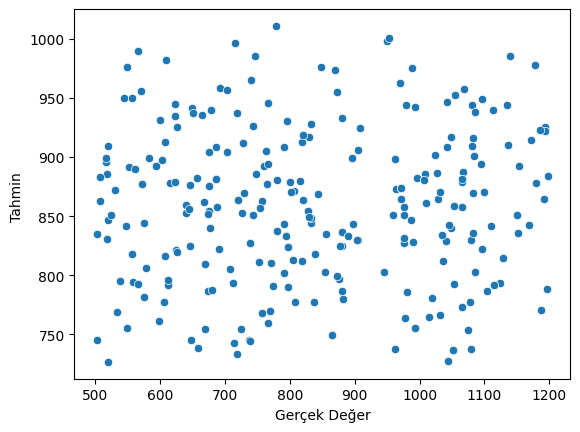

In [235]:
sns.scatterplot(x = "Gerçek Değer", y = "Tahmin ", data = tahminDf)

In [236]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

In [ ]:
mean_absolute_error(tahminDf["Gerçek Değer"], tahminDf["Tahmin "])

181.97443174705595

In [239]:
mean_squared_error(tahminDf["Gerçek Değer"], tahminDf["Tahmin "])

44633.01421117053

In [241]:
dataFrame.describe()

,Fiyat,BisikletOzellik1,BisikletOzellik2
count,1000.000000,1000.000000,1000.000000
mean,852.178025,1750.555541,1750.512794
std,201.478251,2.301770,2.335248
min,502.323508,1746.357159,1746.290159
25%,676.671978,1748.671918,1748.569453
50%,839.514297,1750.629652,1750.597561
75%,1034.775828,1752.407092,1752.491785
max,1200.333756,1754.983732,1754.715630


In [254]:
yeniBisikletOzellik = [[1745,1745]]

In [255]:
yeniBisikletOzellik = sclaler.transform(yeniBisikletOzellik)

In [256]:
model.predict(yeniBisikletOzellik)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[639.1217]], dtype=float32)

modeli kaydetme kısmı

In [260]:
from tensorflow.keras.models import load_model

In [261]:
model.save("bisiklet_model.h5")

In [262]:
sonradanCagilanModel = load_model("bisiklet_model.h5")

ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [263]:
sonradanCagilanModel.predict(yeniBisikletOzellik)

NameError: name 'sonradanCagilanModel' is not defined